In [1]:
from pyspark.sql import SparkSession
from pathlib import Path
import pandas as pd
import math
from pyspark.sql.types import DoubleType, IntegerType, FloatType, LongType, DecimalType
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import trim
import pyspark.sql.functions as F
from pyspark.sql.types import (
    StringType,
    BooleanType,
    IntegerType,
    LongType,
    DoubleType,
    FloatType,
)

spark = (
    SparkSession.builder.appName("Data-Pipeline")
    .config("spark.driver.memory", "6g")
    .config("spark.sql.shuffle.partitions", "16")
    .getOrCreate()
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/25 00:13:22 WARN Utils: Your hostname, Evelyn-Nguyen.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.9 instead (on interface en0)
26/09/25 00:13:22 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/opt/homebrew/opt/apache-spark/libexec/python/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/25 00:13:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
ROOT = next(
    (
        p
        for p in [Path.cwd(), *Path.cwd().parents]
        if ((p / "src").is_dir() and (p / "notebooks").is_dir())
    ),
    Path.cwd(),
)

RAW_DIR = ROOT / "data" / "raw"

cicids = (
    spark.read.option("header", True)
    .option("inferSchema", True)
    .csv(str(RAW_DIR / "CICIDS2017.csv"))
)

In [3]:
def clean_and_deduplicate_col(df):

    seen = set()
    new_columns = []

    for col in df.columns:
        if col == "fwd_header_length.1":
            clean_col = "fwd_header_length"
        else:
            clean_col = col.strip().lower().replace(" ", "_").replace(".", "_").replace("/", "_")

        final_col = clean_col
        i = 1
        while final_col in seen:
            final_col = f"{clean_col}_{i}"
            i += 1

        seen.add(final_col)
        new_columns.append(final_col)

    return df.toDF(*new_columns)

In [4]:
print("=CICIDS=")
cicids = clean_and_deduplicate_col(cicids)
print("Rows:", cicids.count())
print("Columns:", len(cicids.columns))

cicids.show(5, truncate=False)

=CICIDS=


26/09/25 00:13:32 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Rows: 2830743
Columns: 79
+----------------+-------------+-----------------+----------------------+---------------------------+---------------------------+---------------------+---------------------+----------------------+---------------------+---------------------+---------------------+----------------------+---------------------+------------+--------------+-------------+------------+------------+------------+-------------+------------+-----------+-----------+-----------+-------------+------------+-----------+-----------+-----------+-------------+-------------+-------------+-------------+-----------------+-----------------+-------------+-------------+-----------------+-----------------+------------------+-----------------+----------------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+-------------+-------------------+--------------------+--------------------+-------------------+------------------+---------

In [5]:
count_before_cicids = cicids.count()
cicids = cicids.dropDuplicates()


count_after_cicids = cicids.count()
duplicates_removed_cicids = count_before_cicids - count_after_cicids

print(f"Số dòng ban đầu: {count_before_cicids}")
print(f"Số dòng sau khi làm sạch: {count_after_cicids}")
print(f"Đã xóa {duplicates_removed_cicids} dòng trùng lặp.")

Số dòng ban đầu: 2830743
Số dòng sau khi làm sạch: 2522362
Đã xóa 308381 dòng trùng lặp.


In [6]:
def display_missing_value(df):
    total_rows = df.count()

    null_counts = (
        df.select(
            [
                F.sum(F.when(F.col(f"`{c}`").isNull(), 1).otherwise(0)).alias(c)
                for c in df.columns
            ]
        )
        .collect()[0]
        .asDict()
    )

    result_data = []
    for col_name, count in null_counts.items():
        if count > 0:
            percentage = round((count / total_rows) * 100, 2)
            result_data.append((col_name, count, percentage))

    if not result_data:
        print("Không có giá trị Missing nào trong DataFrame!")
    else:
        stats_df = spark.createDataFrame(
            result_data,
            schema=["Column_Name", "Missing_Count", "Missing_Percentage(%)"],
        )
        print(f"Tổng số dòng: {total_rows}")
        stats_df.show(truncate=False)

In [7]:
print("=CICIDS MISSING STATISTICS=")
display_missing_value(cicids)

=CICIDS MISSING STATISTICS=


Không có giá trị Missing nào trong DataFrame!


In [ ]:
string_cols = [
    f.name
    for f in cicids.schema.fields
    if isinstance(f.dataType, (StringType, BooleanType))
]
numeric_cols = [
    f.name
    for f in cicids.schema.fields
    if isinstance(f.dataType, (IntegerType, LongType, DoubleType, FloatType))
]

distinct_counts = (
    cicids.agg(*[F.approx_count_distinct(F.col(c)).alias(c) for c in numeric_cols])
    .collect()[0]
    .asDict()
)

discrete_numeric_cols = []
continuous_numeric_cols = []

THRESHOLD = 50

for col_name, unique_count in distinct_counts.items():
    if unique_count <= THRESHOLD:
        discrete_numeric_cols.append(col_name)
    else:
        continuous_numeric_cols.append(col_name)

final_categorical_cols = string_cols + discrete_numeric_cols

print(
    f"Bỏ qua {len(continuous_numeric_cols)} cột số liên tục: {continuous_numeric_cols[:5]}..."
)
print(f"Tìm thấy {len(final_categorical_cols)} cột Categorical/Rời rạc để đếm.")
print("-" * 50)


for col_name in final_categorical_cols:
    print(f"=== Tần suất giá trị của cột: {col_name} ===")

    cicids.groupBy(col_name).count().orderBy(F.col("count").desc()).show(
        10, truncate=False
    )

26/09/25 00:14:03 WARN DAGScheduler: Broadcasting large task binary with size 1973.4 KiB


Bỏ qua 58 cột số liên tục: ['destination_port', 'flow_duration', 'total_fwd_packets', 'total_backward_packets', 'total_length_of_fwd_packets']...
Tìm thấy 21 cột Categorical/Rời rạc để đếm.
--------------------------------------------------
=== Tần suất giá trị của cột: label ===


+----------------+-------+
|label           |count  |
+----------------+-------+
|BENIGN          |2096484|
|DoS Hulk        |172849 |
|DDoS            |128016 |
|PortScan        |90819  |
|DoS GoldenEye   |10286  |
|FTP-Patator     |5933   |
|DoS slowloris   |5385   |
|DoS Slowhttptest|5228   |
|SSH-Patator     |3219   |
|Bot             |1953   |
+----------------+-------+
only showing top 10 rows
=== Tần suất giá trị của cột: fwd_psh_flags ===


+-------------+-------+
|fwd_psh_flags|count  |
+-------------+-------+
|0            |2399427|
|1            |122935 |
+-------------+-------+

=== Tần suất giá trị của cột: bwd_psh_flags ===


+-------------+-------+
|bwd_psh_flags|count  |
+-------------+-------+
|0            |2522362|
+-------------+-------+

=== Tần suất giá trị của cột: fwd_urg_flags ===


...

+-----------------+-------+
|fwd_avg_bulk_rate|count  |
+-----------------+-------+
|0                |2522362|
+-----------------+-------+

=== Tần suất giá trị của cột: bwd_avg_bytes_bulk ===


+------------------+-------+
|bwd_avg_bytes_bulk|count  |
+------------------+-------+
|0                 |2522362|
+------------------+-------+

=== Tần suất giá trị của cột: bwd_avg_packets_bulk ===


+--------------------+-------+
|bwd_avg_packets_bulk|count  |
+--------------------+-------+
|0                   |2522362|
+--------------------+-------+

=== Tần suất giá trị của cột: bwd_avg_bulk_rate ===


+-----------------+-------+
|bwd_avg_bulk_rate|count  |
+-----------------+-------+
|0                |2522362|
+-----------------+-------+

=== Tần suất giá trị của cột: min_seg_size_forward ===


+--------------------+-------+
|min_seg_size_forward|count  |
+--------------------+-------+
|20                  |1297916|
|32                  |1029020|
|40                  |97791  |
|24                  |82953  |
|44                  |8015   |
|28                  |4421   |
|0                   |1698   |
|56                  |134    |
|36                  |98     |
|60                  |78     |
+--------------------+-------+
only showing top 10 rows


In [9]:
def check_nan_inf(df, numeric_cols):
    print("Đang quét các giá trị NaN, Null và Infinity trên toàn bộ dữ liệu...")
    
    count_exprs = []
    
    for col_name in numeric_cols:
        # 1. Điều kiện đếm NaN / Null (Bắt buộc ép kiểu sang double để hàm isnan không báo lỗi với cột dạng Integer)
        cond_nan_null = F.isnan(F.col(col_name).cast("double")) | F.col(col_name).isNull()
        
        # 2. Điều kiện đếm Infinity (+Inf và -Inf)
        # Bắt cả giá trị float thực tế lẫn biến thể chuỗi do PySpark cast từ CSV
        cond_inf = (
            (F.col(col_name) == float('inf')) | 
            (F.col(col_name) == float('-inf')) | 
            (F.col(col_name).cast("string").isin("Infinity", "-Infinity", "inf", "-inf"))
        )
        
        # Gom vào biểu thức tính tổng
        count_exprs.append(F.sum(F.when(cond_nan_null, 1).otherwise(0)).alias(f"{col_name}_nan"))
        count_exprs.append(F.sum(F.when(cond_inf, 1).otherwise(0)).alias(f"{col_name}_inf"))

    # Thực thi tính toán và thu thập kết quả về dạng Dictionary
    results = df.select(*count_exprs).collect()[0].asDict()
    
    # In báo cáo
    corrupted_cols = []
    print("\n=== BÁO CÁO DỮ LIỆU LỖI (NaN / Inf) ===")
    
    for col_name in numeric_cols:
        nan_count = results[f"{col_name}_nan"]
        inf_count = results[f"{col_name}_inf"]
        
        if nan_count > 0 or inf_count > 0:
            corrupted_cols.append(col_name)
            print(f"[{col_name}]: {nan_count:,} dòng NaN/Null | {inf_count:,} dòng Infinity")
            
    if not corrupted_cols:
        print("hông phát hiện giá trị NaN hay Infinity nào trong các cột số.")
        
    return corrupted_cols


In [10]:
cols_to_check = continuous_numeric_cols 
corrupted_columns = check_nan_inf(cicids, cols_to_check)

Đang quét các giá trị NaN, Null và Infinity trên toàn bộ dữ liệu...



=== BÁO CÁO DỮ LIỆU LỖI (NaN / Inf) ===
[flow_bytes_s]: 353 dòng NaN/Null | 1,211 dòng Infinity
[flow_packets_s]: 0 dòng NaN/Null | 1,564 dòng Infinity


In [11]:
def clean_nan_inf(df, corrupted_cols):
    print(f"\nBắt đầu xóa dòng lỗi trên {len(corrupted_cols)} cột...")
    original_count = df.count()
    
    filter_cond = F.lit(True)
    
    for col_name in corrupted_cols:
        is_valid_number = (
            ~F.isnan(F.col(col_name).cast("double")) & 
            F.col(col_name).isNotNull() & 
            (F.col(col_name) != float('inf')) & 
            (F.col(col_name) != float('-inf')) &
            ~F.col(col_name).cast("string").isin("Infinity", "-Infinity", "inf", "-inf")
        )
        filter_cond = filter_cond & is_valid_number
    df_cleaned = df.filter(filter_cond)
    
    final_count = df_cleaned.count()
    dropped_count = original_count - final_count
    
    print(f"Hoàn tất! Đã xóa {dropped_count:,} dòng lỗi ra khỏi tập dữ liệu.")
    print(f"Số lượng dòng hiện tại: {final_count:,}")
    
    return df_cleaned


In [12]:
cicids = clean_nan_inf(cicids, corrupted_columns)


Bắt đầu xóa dòng lỗi trên 2 cột...


Hoàn tất! Đã xóa 1,564 dòng lỗi ra khỏi tập dữ liệu.
Số lượng dòng hiện tại: 2,520,798


In [13]:
zero_variance_cols = [
    "bwd_psh_flags", 
    "bwd_urg_flags", 
    "fwd_avg_bytes/bulk", 
    "fwd_avg_packets/bulk", 
    "fwd_avg_bulk_rate", 
    "bwd_avg_bytes/bulk", 
    "bwd_avg_packets/bulk", 
    "bwd_avg_bulk_rate"
]

near_zero_variance_cols = [
    "fwd_urg_flags", 
    "cwe_flag_count", 
    "rst_flag_count", 
    "ece_flag_count"
]

cols_to_drop = zero_variance_cols + near_zero_variance_cols

print(f"Tổng số cột chuẩn bị xóa: {len(cols_to_drop)} cột")

cicids = cicids.drop(*cols_to_drop)

print(f"Số lượng cột còn lại sau khi xóa: {len(cicids.columns)} cột")

Tổng số cột chuẩn bị xóa: 12 cột
Số lượng cột còn lại sau khi xóa: 71 cột


### Tương quan và độ lệch của features

- Heatmap Pearson được ước lượng trên mẫu tối đa **20.000 dòng**, không đưa toàn bộ CICIDS vào pandas.
- Loại cột có `|r| > 0.95` với một cột **được giữ lại**; ưu tiên thứ tự cột hiện có. Đây là quy tắc giảm dư thừa, không đánh giá tầm quan trọng dự đoán.
- Loại nhãn khỏi phân tích. Notebook hiện chưa chia train/test nên đây là **EDA trên toàn bộ CICIDS**. Khi xây dựng đánh giá holdout, chọn cột và phép log trên train rồi áp dụng cùng danh sách lên validation/test.
- Skewness tính bằng Spark trên toàn bộ dữ liệu phân tích. Chỉ đề xuất `log1p` cho cột lệch phải (`skewness > 1`), không âm và không phải cột nhị phân/port. Cột lệch trái hoặc có giá trị âm được liệt kê để xem xét riêng.

/opt/homebrew/opt/apache-spark/libexec/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Heatmap sử dụng 20,000 / 2,520,798 dòng.
Cột chưa tính được tương quan trên mẫu: ['fwd_avg_bytes_bulk', 'fwd_avg_packets_bulk', 'bwd_avg_bytes_bulk', 'bwd_avg_packets_bulk']


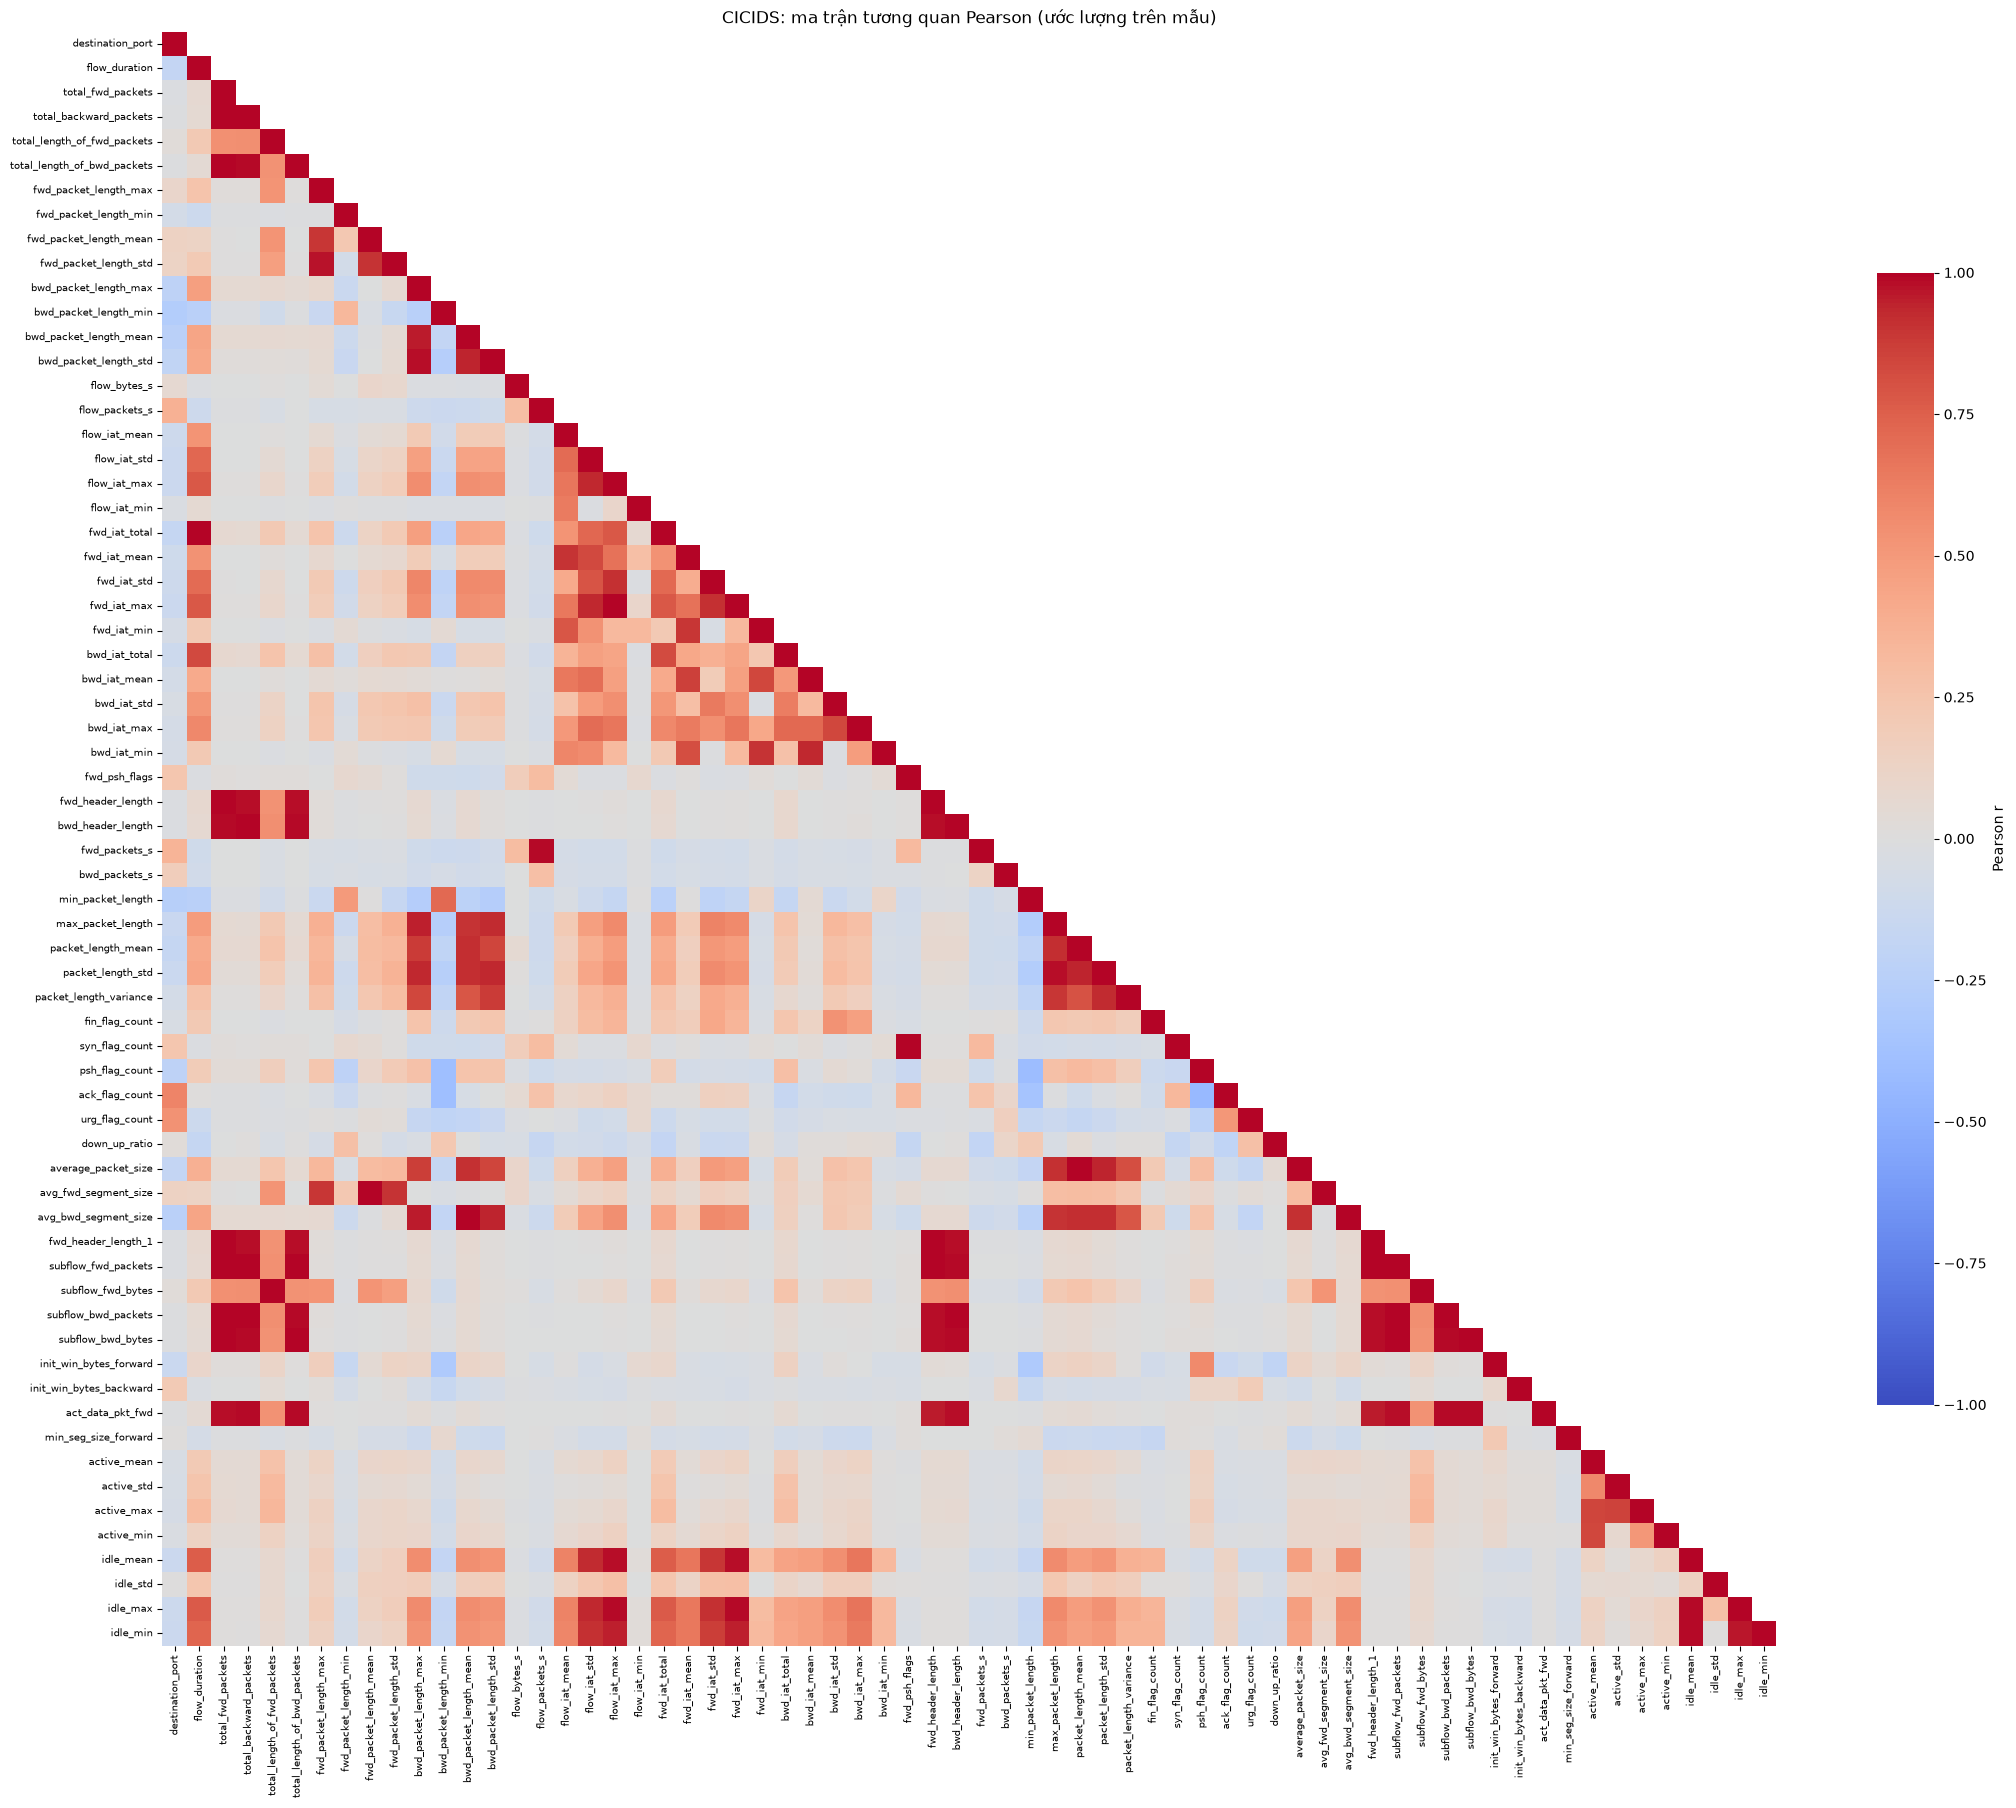

In [14]:
import numpy as np
from pyspark.sql.types import NumericType
from IPython.display import display

CORR_THRESHOLD = 0.95
SKEW_THRESHOLD = 1.0
MAX_SAMPLE_ROWS = 20_000
EXCLUDED_COLUMNS = {"label", "binary_label", "label_clean", "attack_cat", "id"}

# Giữ bản trước khi lọc để có thể chạy lại các cell EDA.
cicids_before_selection = cicids
feature_columns = [
    field.name for field in cicids_before_selection.schema.fields
    if isinstance(field.dataType, NumericType)
    and field.name.lower() not in EXCLUDED_COLUMNS
]
if not feature_columns:
    raise ValueError("Không có features dạng số để phân tích.")

# Chuyển NaN/Inf thành null chỉ trong dữ liệu phân tích.
clean_columns = []
for name in feature_columns:
    value = F.col(name).cast("double")
    valid = value.isNotNull() & ~F.isnan(value) & (F.abs(value) != float("inf"))
    clean_columns.append(F.when(valid, value).alias(name))
analysis_data = cicids_before_selection.select(*clean_columns)

row_count = analysis_data.count()
if row_count < 3:
    raise ValueError("Cần ít nhất 3 dòng để phân tích.")
sample_fraction = min(1.0, MAX_SAMPLE_ROWS / row_count)
eda_sample = (
    analysis_data.sample(False, sample_fraction, seed=42)
    .limit(MAX_SAMPLE_ROWS)
    .toPandas()
)
print(f"Heatmap sử dụng {len(eda_sample):,} / {row_count:,} dòng.")

# Cột hằng trên mẫu không có Pearson xác định, không tự động loại chúng.
corr_df = eda_sample.corr(method="pearson", min_periods=3)
undefined_columns = corr_df.columns[corr_df.isna().all()].tolist()
print("Cột chưa tính được tương quan trên mẫu:", undefined_columns)
corr_plot = corr_df.drop(index=undefined_columns, columns=undefined_columns)

if len(corr_plot) >= 2:
    plt.figure(figsize=(22, 18))
    mask = np.triu(np.ones(corr_plot.shape, dtype=bool), k=1)
    sns.heatmap(
        corr_plot, mask=mask, cmap="coolwarm", center=0,
        vmin=-1, vmax=1, square=True, annot=False,
        xticklabels=True, yticklabels=True,
        cbar_kws={"label": "Pearson r", "shrink": 0.7},
    )
    plt.title("CICIDS: ma trận tương quan Pearson (ước lượng trên mẫu)")
    plt.xticks(rotation=90, fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    plt.show()
else:
    print("Không đủ cột có tương quan xác định để vẽ heatmap.")

In [15]:
# Liệt kê tất cả cặp tương quan cao.
high_corr_pairs = []
for i, column in enumerate(feature_columns):
    for previous in feature_columns[:i]:
        correlation = corr_df.loc[column, previous]
        if pd.notna(correlation) and abs(correlation) > CORR_THRESHOLD:
            high_corr_pairs.append({
                "column_1": previous, "column_2": column,
                "correlation": correlation,
            })
display(pd.DataFrame(high_corr_pairs, columns=["column_1", "column_2", "correlation"]))

# Chỉ loại nếu tương quan cao với một cột đã GIỮ, không với cột đã loại.
kept_columns = []
drop_reasons = []
for column in feature_columns:
    for kept in kept_columns:
        correlation = corr_df.loc[column, kept]
        if pd.notna(correlation) and abs(correlation) > CORR_THRESHOLD:
            drop_reasons.append({
                "drop": column, "keep": kept, "correlation": correlation,
            })
            break
    else:
        kept_columns.append(column)

multicollinear_cols_to_drop = [row["drop"] for row in drop_reasons]
display(pd.DataFrame(drop_reasons, columns=["drop", "keep", "correlation"]))
print("Các cột loại bỏ:", multicollinear_cols_to_drop)

# Cell xuất Parquet phía dưới sẽ dùng dữ liệu đã lọc này (chưa log).
cicids = cicids_before_selection.drop(*multicollinear_cols_to_drop)
train_data = cicids  # Tên cũ; đây chưa phải một train split.
print(f"Giữ {len(kept_columns)} / {len(feature_columns)} features dạng số.")

,column_1,column_2,correlation
0,total_fwd_packets,total_backward_packets,0.992824
1,total_fwd_packets,total_length_of_bwd_packets,0.993988
2,total_backward_packets,total_length_of_bwd_packets,0.992054
3,fwd_packet_length_max,fwd_packet_length_std,0.974867
4,bwd_packet_length_max,bwd_packet_length_mean,0.958993
...,...,...,...
62,idle_mean,idle_max,0.990571
63,flow_iat_max,idle_min,0.952496
64,fwd_iat_max,idle_min,0.950132
65,idle_mean,idle_min,0.990180


,drop,keep,correlation
0,total_backward_packets,total_fwd_packets,0.992824
1,total_length_of_bwd_packets,total_fwd_packets,0.993988
2,fwd_packet_length_std,fwd_packet_length_max,0.974867
3,bwd_packet_length_mean,bwd_packet_length_max,0.958993
4,bwd_packet_length_std,bwd_packet_length_max,0.981551
5,fwd_iat_total,flow_duration,0.998790
6,fwd_iat_max,flow_iat_max,0.998409
7,fwd_header_length,total_fwd_packets,0.992824
8,bwd_header_length,total_fwd_packets,0.989978
9,fwd_packets_s,flow_packets_s,0.986226


Các cột loại bỏ: ['total_backward_packets', 'total_length_of_bwd_packets', 'fwd_packet_length_std', 'bwd_packet_length_mean', 'bwd_packet_length_std', 'fwd_iat_total', 'fwd_iat_max', 'fwd_header_length', 'bwd_header_length', 'fwd_packets_s', 'packet_length_std', 'syn_flag_count', 'average_packet_size', 'avg_fwd_segment_size', 'avg_bwd_segment_size', 'fwd_header_length_1', 'subflow_fwd_packets', 'subflow_fwd_bytes', 'subflow_bwd_packets', 'subflow_bwd_bytes', 'act_data_pkt_fwd', 'idle_mean', 'idle_max', 'idle_min']
Giữ 46 / 70 features dạng số.


In [16]:
# Tính thống kê trên Spark, chỉ collect một dòng tổng hợp.
aggregations = []
for index, name in enumerate(kept_columns):
    aggregations.extend([
        F.skewness(name).alias(f"skew_{index}"),
        F.min(name).alias(f"min_{index}"),
        F.max(name).alias(f"max_{index}"),
        F.approx_count_distinct(name).alias(f"unique_{index}"),
    ])
statistics = analysis_data.agg(*aggregations).first().asDict()

# Port là mã định danh, không chọn log chỉ vì phân phối lệch.
NO_LOG_COLUMNS = {"destination_port", "source_port", "protocol"}
skew_rows = []
for index, name in enumerate(kept_columns):
    skew = statistics[f"skew_{index}"]
    minimum = statistics[f"min_{index}"]
    unique_count = statistics[f"unique_{index}"]
    use_log = (
        skew is not None and np.isfinite(skew) and skew > SKEW_THRESHOLD
        and minimum is not None and minimum >= 0
        and unique_count > 2 and name not in NO_LOG_COLUMNS
    )
    skew_rows.append({
        "feature": name, "skewness": skew, "min": minimum,
        "max": statistics[f"max_{index}"],
        "approx_unique": unique_count, "use_log1p": use_log,
    })

skew_table = pd.DataFrame(skew_rows)
skew_table["abs_skewness"] = skew_table["skewness"].abs()
skew_table = skew_table.sort_values("abs_skewness", ascending=False)
display(skew_table)

log_columns = skew_table.loc[skew_table["use_log1p"], "feature"].tolist()
review_columns = skew_table.loc[
    (skew_table["abs_skewness"] > SKEW_THRESHOLD) & ~skew_table["use_log1p"],
    "feature",
].tolist()
print("Đề xuất log1p:", log_columns)
print("Lệch mạnh nhưng cần xem xét riêng (âm/nhị phân/port/lệch trái):", review_columns)

# Bản riêng để thử nghiệm; cicids xuất phía dưới vẫn CHƯA log.
# Không đưa cicids_log qua log lần nữa ở pipeline downstream.
cicids_log = cicids
for name in log_columns:
    cicids_log = cicids_log.withColumn(name, F.log1p(F.col(name)))

26/09/25 00:16:43 WARN DAGScheduler: Broadcasting large task binary with size 1059.9 KiB
26/09/25 00:16:54 WARN DAGScheduler: Broadcasting large task binary with size 1814.1 KiB


,feature,skewness,min,max,approx_unique,use_log1p,abs_skewness
3,total_length_of_fwd_packets,760.580989,0.0,1.290000e+07,16189,True,760.580989
40,min_seg_size_forward,-447.802717,-536870661.0,1.380000e+02,28,False,447.802717
2,total_fwd_packets,230.614654,1.0,2.197590e+05,1444,True,230.614654
9,flow_bytes_s,45.672350,-261000000.0,2.071000e+09,1574193,False,45.672350
44,active_min,45.047543,0.0,1.100000e+08,185875,True,45.047543
42,active_std,38.232638,0.0,7.420000e+07,187357,True,38.232638
41,active_mean,36.141578,0.0,1.100000e+08,357283,True,36.141578
14,flow_iat_min,23.481744,-14.0,1.200000e+08,126974,False,23.481744
43,active_max,23.023113,0.0,1.100000e+08,312462,True,23.023113
24,bwd_packets_s,21.706681,0.0,2.000000e+06,1056769,True,21.706681


Đề xuất log1p: ['total_length_of_fwd_packets', 'total_fwd_packets', 'active_min', 'active_std', 'active_mean', 'active_max', 'bwd_packets_s', 'fwd_packet_length_min', 'down_up_ratio', 'min_packet_length', 'idle_std', 'bwd_iat_min', 'fwd_packet_length_max', 'fwd_packet_length_mean', 'bwd_iat_mean', 'fwd_iat_mean', 'bwd_iat_std', 'packet_length_variance', 'bwd_packet_length_min', 'bwd_iat_max', 'flow_iat_std', 'fwd_iat_std', 'bwd_packet_length_max', 'bwd_iat_total', 'max_packet_length', 'packet_length_mean']
Lệch mạnh nhưng cần xem xét riêng (âm/nhị phân/port/lệch trái): ['min_seg_size_forward', 'flow_bytes_s', 'flow_iat_min', 'fwd_iat_min', 'flow_iat_mean', 'flow_packets_s', 'fin_flag_count', 'init_win_bytes_backward', 'fwd_psh_flags', 'flow_iat_max', 'urg_flag_count', 'init_win_bytes_forward', 'flow_duration', 'destination_port']


,before_log,after_log1p,improved
total_length_of_fwd_packets,22.319306,-0.148059,True
total_fwd_packets,87.396275,1.761568,True
active_min,14.312576,1.646963,True
active_std,23.738941,3.257280,True
active_mean,15.001139,1.651215,True
active_max,15.083833,1.681159,True
bwd_packets_s,18.255330,0.662301,True
fwd_packet_length_min,20.194350,0.293758,True
down_up_ratio,2.563368,-0.056847,True
min_packet_length,11.927460,0.289156,True


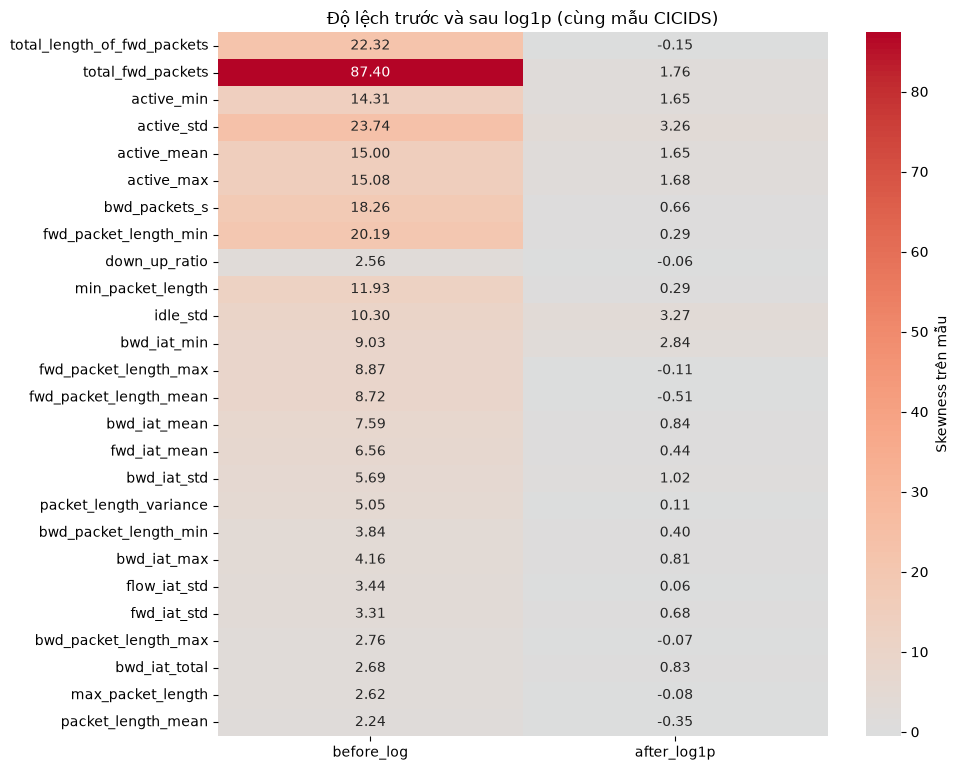

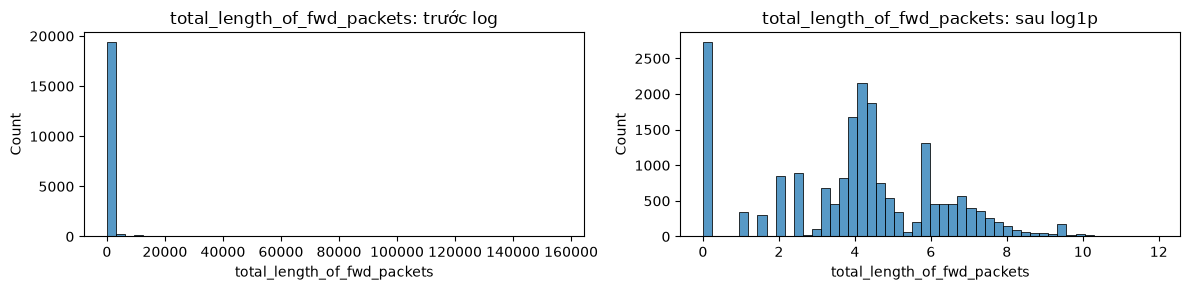

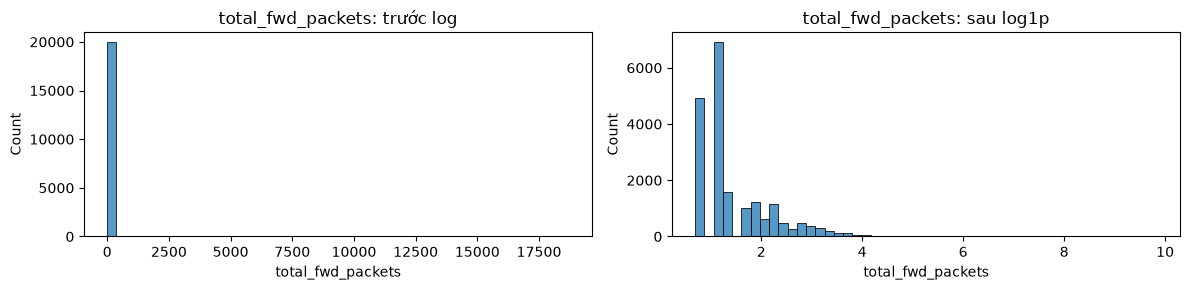

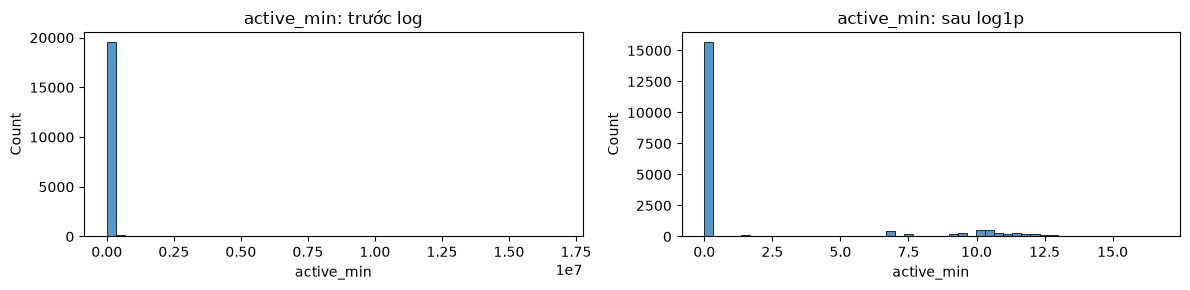

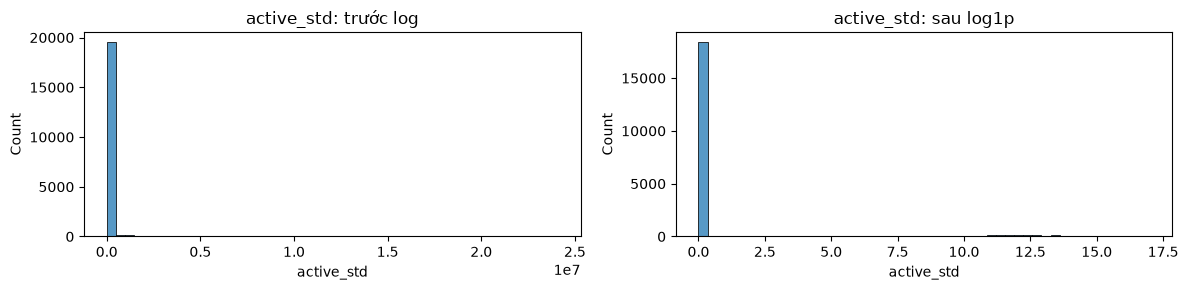

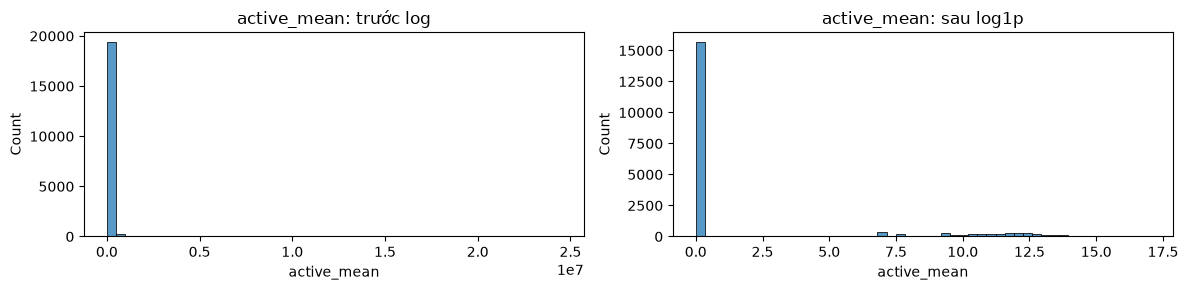

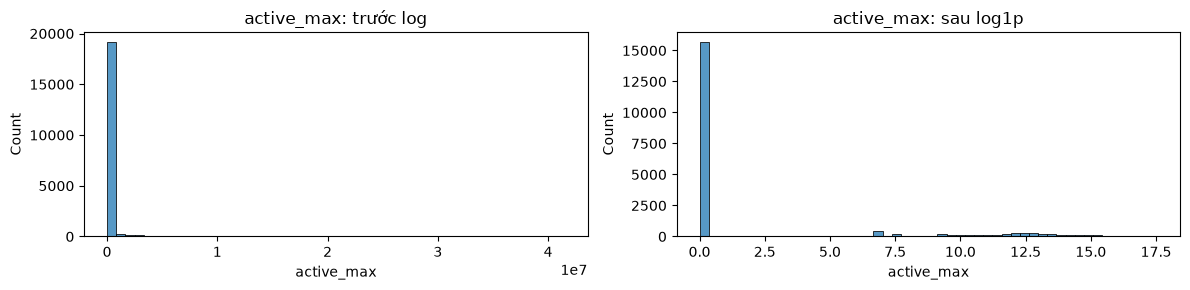

In [17]:
# So sánh độ lệch trước/sau trên cùng mẫu; không mặc định log luôn cải thiện.
if log_columns:
    log_sample = eda_sample[log_columns].copy()
    before_skew = log_sample.skew()
    after_skew = np.log1p(log_sample).skew()
    comparison = pd.DataFrame({"before_log": before_skew, "after_log1p": after_skew})
    comparison["improved"] = comparison["after_log1p"].abs() < comparison["before_log"].abs()
    display(comparison)

    plt.figure(figsize=(10, max(4, len(log_columns) * 0.3)))
    sns.heatmap(
        comparison[["before_log", "after_log1p"]],
        cmap="coolwarm", center=0, annot=True, fmt=".2f",
        cbar_kws={"label": "Skewness trên mẫu"},
    )
    plt.title("Độ lệch trước và sau log1p (cùng mẫu CICIDS)")
    plt.tight_layout()
    plt.show()

    # Histogram của tối đa 6 cột lệch mạnh nhất.
    for name in log_columns[:6]:
        values = eda_sample[name].dropna()
        fig, axes = plt.subplots(1, 2, figsize=(12, 3))
        sns.histplot(values, bins=50, ax=axes[0])
        sns.histplot(np.log1p(values), bins=50, ax=axes[1])
        axes[0].set_title(f"{name}: trước log")
        axes[1].set_title(f"{name}: sau log1p")
        plt.tight_layout()
        plt.show()
else:
    print("Không có cột đáp ứng tiêu chí log1p.")

In [18]:
label_clean = F.upper(F.trim(F.col("label")))

cicids = cicids.withColumn(
    "binary_label",
    F.when(
        label_clean.isNull() | (label_clean == ""),
        F.lit(None).cast("int")
    )
    .when(label_clean == "BENIGN", 0)
    .otherwise(1)
)

# Kiểm tra kết quả
cicids.groupBy("label", "binary_label").count().show(truncate=False)

+----------------------------+------------+-------+
|label                       |binary_label|count  |
+----------------------------+------------+-------+
|BENIGN                      |0           |2095057|
|SSH-Patator                 |1           |3219   |
|DDoS                        |1           |128014 |
|Web Attack ï¿½ Brute Force  |1           |1470   |
|FTP-Patator                 |1           |5931   |
|DoS slowloris               |1           |5385   |
|Bot                         |1           |1948   |
|PortScan                    |1           |90694  |
|DoS Slowhttptest            |1           |5228   |
|Infiltration                |1           |36     |
|Heartbleed                  |1           |11     |
|Web Attack ï¿½ XSS          |1           |652    |
|DoS Hulk                    |1           |172846 |
|DoS GoldenEye               |1           |10286  |
|Web Attack ï¿½ Sql Injection|1           |21     |
+----------------------------+------------+-------+



In [19]:
parquet_path = '/Users/thonph/Desktop/KLTN/data/processed/clean_cicids.parquet'
cicids.write.mode("overwrite").parquet(parquet_path)

In [20]:
spark.stop

<bound method SparkSession.stop of <pyspark.sql.session.SparkSession object at 0x11ab8a8a0>>